# 01 EDA Análisis Exploratorio de Datos

Este notebook realiza el análisis exploratorio del dataset APS usando **solo train**. No se carga **test.csv** porque el objetivo del EDA es entender los datos de entrenamiento sin contaminar la evaluación final.

El EDA sirve para justificar decisiones posteriores. Aquí se estudian el desbalanceo, los valores faltantes, los valores extremos y las correlaciones. Estas observaciones ayudan a elegir métricas y a diseñar Pipelines, pero no se usan para ajustar hiperparámetros con test.

Mirar test durante el EDA sería una mala práctica porque podría influir en decisiones que parecen descriptivas. Por ejemplo, si se observa una variable problemática en test, se podría decidir eliminarla o tratarla de una forma concreta. Eso convertiría test en parte del diseño experimental.

Por esa razón, este notebook actúa como una exploración controlada. Todo lo que se aprende aquí procede de train y sirve para justificar decisiones generales. La evaluación final sigue quedando protegida.

## Preparación del EDA

Esta celda carga las librerías necesarias para analizar tablas y crear figuras. También crea las carpetas donde se guardarán las salidas del análisis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from project_utils import cargar_csv, crear_carpetas, guardar_figura, obtener_variables_numericas

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

crear_carpetas(".")

## Carga de train

Esta sección carga únicamente **data/processed/train.csv**. La partición de test no aparece en este notebook para evitar que el análisis exploratorio influya en decisiones usando información reservada.

Esta separación es importante porque incluso decisiones aparentemente pequeñas, como eliminar variables o cambiar métricas mirando test, podrían sesgar la evaluación final. Por eso todo el razonamiento exploratorio se limita a train.

In [ ]:
train = cargar_csv("data/processed/train.csv")
train.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,...,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,...,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,0,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,...,NaN,NaN,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,0,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,...,0.0,2341048.0,1494.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13876.0,38182.0,8138.0,0.0,0.0,65772.0,10534.0,300240.0,48028.0,0.0,0.0,0.0,0.0,1040120.0,1018.64,1020.0,262032.0,453378.0,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,0,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,3232.0,1872.0,0.0,0.0,0.0,2668.0,0.0,0.0,0.0,642.0,3894.0,10184.0,7554.0,10764.0,1014.0,0.0,0.0,0.0,0.0,60.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2578.0,76.0,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,232.0,0.0,0.0,2014.0,370.0,48.0,18.0,15740.0,1822.0,20174.0,44.0,0.0,0.0,0.0,1.08,54.0,5670.0,1566.0,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,0,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,1966618.0,1800340.0,131646.0,4588.0,0.0,1974038.0,0.0,226.0,0.0,0.0,0.0,3230626.0,2618878.0,1058136.0,551022.0,0.0,0.0,0.0,0.0,1788.0,642.0,0.0,0.0,0.0,0.0,42124.0,372236.0,2128914.0,...,0.0,3590004.0,2026.0,444.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44946.0,62648.0,11506.0,0.0,0.0,149474.0,35154.0,457040.0,80482.0,98334.0,27588.0,0.0,0.0,21173050.0,1116.06,1176.0,404740.0,904230.0,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


La vista inicial confirma que el dataset tiene formato tabular. Cada fila representa un caso de mantenimiento y cada columna contiene una variable del sistema. La variable objetivo se llama **class** y permite distinguir entre casos negativos y positivos.

Las variables predictoras son numéricas. Proceden de sensores, contadores o agregados internos del camión. Aunque sus nombres están anonimizados, siguen siendo útiles para el aprendizaje automático porque describen el estado del sistema en cada caso.

Esta estructura encaja bien con los modelos vistos en la asignatura, como regresión logística, SVM, árboles y métodos de boosting. También muestra dos necesidades importantes. Primero, hay que tratar los valores faltantes porque muchos modelos no pueden trabajar directamente con ellos. Segundo, algunos modelos necesitan escalado porque son sensibles a la magnitud de las variables.

Por eso, en los notebooks de modelado la imputación y el escalado se incluirán dentro del **Pipeline**. Así se evita fuga de información y cada transformación se aprende solo con los datos que corresponden dentro de cada fold de validación cruzada.

## Tamaño de train

Esta celda calcula el número de filas, columnas y variables predictoras. Documentar la escala del dataset es útil porque condiciona el coste computacional de los modelos y la viabilidad de la validación cruzada.

El tamaño también ayuda a defender que el problema tiene suficiente entidad. No se trata de un ejemplo pequeño, sino de un conjunto industrial con muchas variables y miles de observaciones.

In [ ]:
n_filas, n_columnas = train.shape
n_variables = n_columnas - 1

info_train = pd.DataFrame({
    "dato": ["filas_train", "columnas_totales", "variables_predictoras"],
    "valor": [n_filas, n_columnas, n_variables]
})

info_train.to_csv("artifacts/metrics/train_size.csv", index=False)
info_train

,dato,valor
0,filas_train,60000
1,columnas_totales,171
2,variables_predictoras,170


Train contiene **60000 filas** y **170 variables predictoras**. Es una escala adecuada para comparar varios modelos con 5-fold CV.

El número de variables también indica que puede haber redundancia, missing values y relaciones no lineales. Por eso se comparan modelos de distinta naturaleza en los notebooks posteriores.

## Variable objetivo

Esta sección analiza la distribución de **class**. La clase 1 representa fallos APS y es la clase que más interesa detectar.

El objetivo no es solo saber cuántos casos hay de cada clase. También se quiere medir si el problema está desbalanceado y qué consecuencias tendrá para las métricas de evaluación.

In [ ]:
target = "class"

class_counts = train[target].value_counts().sort_index()
class_props = train[target].value_counts(normalize=True).sort_index()

class_distribution = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "proportion": class_props.values
})

class_distribution.to_csv("artifacts/metrics/class_distribution_train.csv", index=False)
class_distribution

,class,count,proportion
0,0,59000,0.983333
1,1,1000,0.016667


La tabla muestra **59000 negativos** y **1000 positivos**. La clase positiva representa aproximadamente **1.67%** de train.

Este desbalanceo es muy relevante. Un modelo que ignore la clase positiva podría acertar la mayoría de las filas y aun así fallar justo en los casos importantes. Por eso el proyecto debe mirar métricas centradas en la clase positiva.
Esta proporción tiene una consecuencia clara para la memoria. La accuracy debe presentarse con cuidado y nunca como métrica principal. En un problema con solo 1.67% de positivos, acertar negativos es fácil y detectar positivos es lo realmente valioso.

El análisis de clases también anticipa el análisis de coste. Si los positivos son pocos y además los falsos negativos son caros, el modelo debe evaluarse desde una perspectiva sensible al riesgo.

## Gráfica de clases

Esta figura representa visualmente el desbalanceo de la variable objetivo. La gráfica facilita ver la diferencia entre clases sin depender solo de la tabla.

En un problema industrial como este, la visualización ayuda a comunicar por qué la clase minoritaria merece una atención específica.

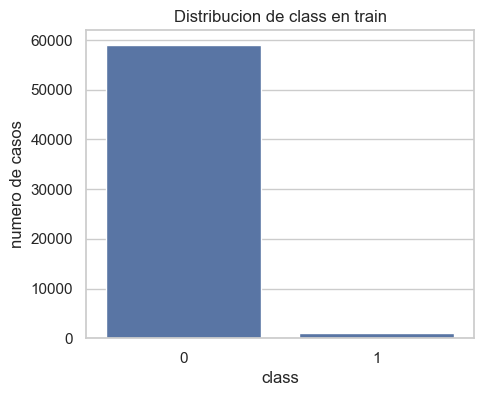

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=class_distribution, x="class", y="count", ax=ax)
ax.set_title("Distribucion de class en train")
ax.set_xlabel("class")
ax.set_ylabel("numero de casos")
guardar_figura(fig, "artifacts/figures/class_distribution_train.png")
plt.show()

La gráfica confirma que la clase negativa domina claramente el dataset. Esta situación hace que accuracy sea una métrica incompleta.

Si un clasificador predice casi todo como negativo, puede parecer bueno en accuracy, pero no sería útil para mantenimiento predictivo. Detectar positivos requiere mirar recall, F1, PR-AUC y coste.

## Resumen del desbalanceo

Esta sección guarda una tabla con la proporción de positivos y negativos. La tabla se usa como evidencia sencilla para justificar la elección de métricas.

El desbalanceo no se corrige todavía. En esta fase solo se documenta el problema para que el modelado posterior lo trate de forma controlada y dentro del protocolo experimental.

In [ ]:
positive_label = 1 if 1 in set(train[target].dropna().unique()) else "pos"
negative_label = 0 if 0 in set(train[target].dropna().unique()) else "neg"

positive_count = int((train[target] == positive_label).sum()) if positive_label in set(train[target].unique()) else np.nan
negative_count = int((train[target] == negative_label).sum()) if negative_label in set(train[target].unique()) else np.nan
positive_rate = float((train[target] == positive_label).mean()) if positive_label in set(train[target].unique()) else np.nan
negative_rate = float((train[target] == negative_label).mean()) if negative_label in set(train[target].unique()) else np.nan

imbalance_summary = pd.DataFrame({
    "metric": ["negative_count", "positive_count", "negative_rate", "positive_rate"],
    "value": [negative_count, positive_count, negative_rate, positive_rate]
})

imbalance_summary.to_csv("artifacts/metrics/imbalance_summary_train.csv", index=False)
imbalance_summary

,metric,value
0,negative_count,59000.000000
1,positive_count,1000.000000
2,negative_rate,0.983333
3,positive_rate,0.016667


El resumen confirma que los positivos son una minoría clara. Por eso accuracy se mantiene solo como referencia general.

Las métricas principales del proyecto deben medir la detección de fallos APS. Recall positivo mide cuántos fallos se detectan. F1 resume el equilibrio entre detección y precisión. PR-AUC es especialmente útil cuando la clase positiva es escasa.

## Missing values generales

Esta sección calcula los valores faltantes por variable. En datos industriales, los missing pueden aparecer por fallos de sensores, registros incompletos o condiciones en las que una medida no se toma.

Los missing no se tratan como un detalle menor. Pueden afectar al rendimiento y también pueden contener información indirecta sobre el estado del sistema. Por eso se analizan, pero la imputación se deja para los Pipelines de modelado.

In [ ]:
missing_total = train.isna().sum()
missing_rate = train.isna().mean()

missing_summary = pd.DataFrame({
    "column": missing_total.index,
    "missing_count": missing_total.values,
    "missing_rate": missing_rate.values
}).sort_values("missing_rate", ascending=False)

missing_summary.to_csv("artifacts/metrics/missing_values_train.csv", index=False)
missing_summary.head(30)

,column,missing_count,missing_rate
79,br_000,49264,0.821067
78,bq_000,48722,0.812033
77,bp_000,47740,0.795667
76,bo_000,46333,0.772217
2,ab_000,46329,0.772150
113,cr_000,46329,0.772150
75,bn_000,44009,0.733483
74,bm_000,39549,0.659150
73,bl_000,27277,0.454617
72,bk_000,23034,0.383900


La tabla muestra variables con una proporción elevada de missing. Esto confirma que el preprocesamiento será una parte central del proyecto.

No se eliminan variables de forma automática en el EDA. Hacerlo de forma manual podría introducir decisiones difíciles de justificar. En datos de sensores, un missing puede significar más que una simple ausencia. Puede aparecer porque un sensor no registró una medida, porque una condición no se activó o porque el proceso de captura tiene reglas internas. Por eso eliminar columnas solo por tener missing sería una decisión demasiado agresiva.

La estrategia elegida es conservar las variables y tratar los missing mediante imputación. En los modelos se usa **SimpleImputer(strategy="median")**, que sustituye los valores faltantes por la mediana de cada variable. La mediana es una opción razonable porque el dataset tiene valores extremos y distribuciones muy asimétricas. En ese contexto, la media podría verse más afectada por valores anómalos.

La imputación se incluye dentro del **Pipeline**. Esto es importante porque la mediana no se calcula usando todo el dataset antes de entrenar. En cada fold de validación cruzada, la mediana se aprende solo con la parte de entrenamiento de ese fold y luego se aplica a la parte de validación. De esta forma se evita fuga de información.

Esta decisión también mantiene el test protegido. Los valores de test se imputan usando las medianas aprendidas en train por el modelo ya fijado. Test no participa en el cálculo de la imputación ni en ninguna decisión de preprocesamiento.

## Variables con más missing

Esta figura muestra las 30 variables con mayor proporción de valores faltantes en train. El objetivo es ver si los missing están concentrados en pocas columnas o si aparecen repartidos por muchas variables del sistema.

Las variables del dataset están anonimizadas, por lo que no conocemos el significado físico exacto de cada nombre. Aun así, se pueden interpretar como medidas, contadores o agregados internos asociados al funcionamiento del camión. Por eso una columna con muchos missing puede representar un sensor que no siempre registra datos, una señal que solo aparece bajo ciertas condiciones o una variable que depende de un evento concreto del sistema.

Esta visualización ayuda a justificar que los datos APS no son limpios de forma ideal. Esto es normal en un contexto industrial con sensores reales. También refuerza la decisión de no eliminar columnas de forma automática durante el EDA. En su lugar, los valores faltantes se tratarán dentro del **Pipeline** mediante imputación, evitando fuga de información entre train, validación y test.

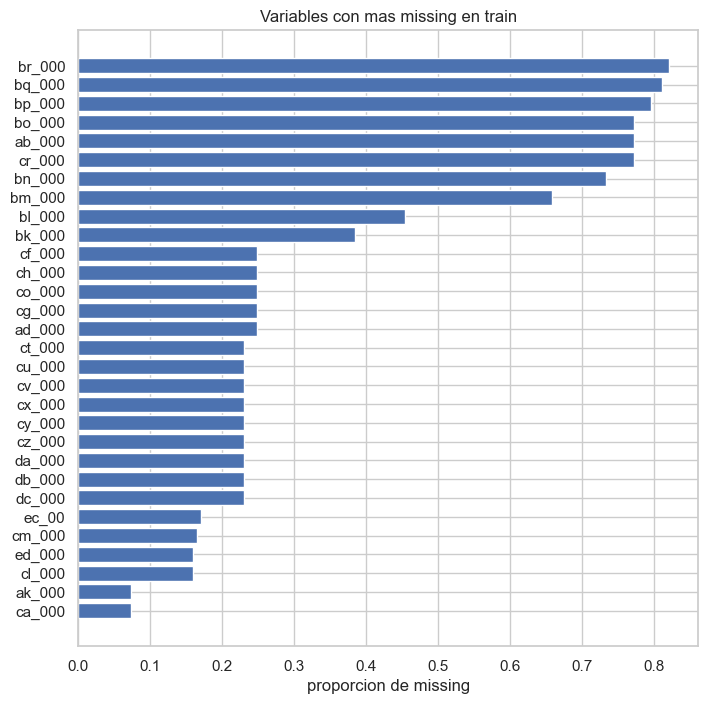

In [ ]:
top_missing = missing_summary.head(30).sort_values("missing_rate")

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_missing["column"], top_missing["missing_rate"])
ax.set_title("Variables con mas missing en train")
ax.set_xlabel("proporcion de missing")
guardar_figura(fig, "artifacts/figures/missing_values_top30.png")
plt.show()

La figura confirma que los valores faltantes son una característica importante del dataset. No es un detalle aislado ni algo que pueda ignorarse antes de entrenar los modelos.

La decisión metodológica es usar imputación dentro del **Pipeline**. Así, en cada fold de validación cruzada, los valores de imputación se calculan solo con la parte de entrenamiento. Test queda fuera de este proceso y se mantiene como evaluación final independiente.

## Missing por clase

Esta sección compara la proporción de valores faltantes entre casos negativos y positivos usando solo train. El objetivo es comprobar si los missing aparecen de forma similar en ambas clases o si son más frecuentes en los fallos APS.

En un sistema industrial, la ausencia de una medida también puede aportar información. Un valor puede faltar porque un sensor no registró datos, porque una condición del sistema no se activó o porque el proceso de captura depende del estado del vehículo.

Este análisis ayuda a entender mejor el dataset, pero no se usa para ajustar modelos ni para tomar decisiones con test. Su función es justificar que el tratamiento de missing debe hacerse de forma cuidadosa dentro del **Pipeline**.

In [ ]:
features = [col for col in train.columns if col != target]
missing_by_class = train.groupby(target)[features].apply(lambda x: x.isna().mean())
missing_by_class = missing_by_class.T.reset_index().rename(columns={"index": "column"})

missing_by_class.to_csv("artifacts/metrics/missing_by_class_train.csv", index=False)
missing_by_class.head(20)

class,column,0,1
0,aa_000,0.000000,0.000
1,ab_000,0.772169,0.771
2,ac_000,0.048695,0.462
3,ad_000,0.240949,0.645
4,ae_000,0.036593,0.341
5,af_000,0.036593,0.341
6,ag_000,0.011305,0.004
7,ag_001,0.011305,0.004
8,ag_002,0.011305,0.004
9,ag_003,0.011305,0.004


La tabla permite ver que algunas variables tienen una proporción de missing parecida en ambas clases, como **ab_000**, mientras que otras cambian mucho entre negativos y positivos. Por ejemplo, **ac_000**, **ad_000**, **ae_000**, **af_000** y **ak_000** tienen muchos más valores faltantes en la clase positiva.

Esto es importante porque la ausencia de una medida no parece ser solo ruido aleatorio. En algunos casos puede estar relacionada con el estado del sistema o con el proceso de registro del fallo APS.

No se eliminan variables ni se ajustan hiperparámetros a partir de esta tabla. Su función es apoyar la interpretación y reforzar la necesidad de un preprocesamiento correcto dentro de los **Pipeline**.

## Diferencia de missing por clase

Esta sección ordena las variables donde más cambia la proporción de missing entre positivos y negativos. El objetivo es localizar patrones de ausencia que puedan estar asociados al fallo APS.

El análisis sigue limitado a train. Por tanto, no contamina la evaluación final y no usa información de test para diseñar el modelo.

In [ ]:
class_cols = [col for col in missing_by_class.columns if col != "column"]

if len(class_cols) >= 2:
    diff = missing_by_class[class_cols].max(axis=1) - missing_by_class[class_cols].min(axis=1)
    missing_class_diff = missing_by_class.copy()
    missing_class_diff["max_difference"] = diff
    missing_class_diff = missing_class_diff.sort_values("max_difference", ascending=False)
else:
    missing_class_diff = missing_by_class.copy()
    missing_class_diff["max_difference"] = np.nan

missing_class_diff.to_csv("artifacts/metrics/missing_by_class_difference_train.csv", index=False)
missing_class_diff.head(20)

class,column,0,1,max_difference
78,br_000,0.833458,0.090,0.743458
77,bq_000,0.824322,0.087,0.737322
76,bp_000,0.807746,0.083,0.724746
75,bo_000,0.783983,0.078,0.705983
74,bn_000,0.744661,0.074,0.670661
73,bm_000,0.669119,0.071,0.598119
19,ak_000,0.065559,0.532,0.466441
86,ca_000,0.064847,0.530,0.465153
137,di_000,0.059017,0.524,0.464983
155,eb_000,0.059034,0.524,0.464966


Las diferencias de missing por clase son grandes en algunas variables. Por ejemplo, **br_000**, **bq_000**, **bp_000**, **bo_000** y **bn_000** tienen muchos más valores faltantes en la clase negativa que en la positiva. En cambio, variables como **ak_000**, **ca_000**, **di_000**, **eb_000** y varias del grupo **d** tienen más missing en la clase positiva.

Esto indica que los valores faltantes no aparecen siempre de forma uniforme. En un dataset industrial, la ausencia de una medida puede depender del estado del sistema, del sensor que registra la señal o de las condiciones en las que se recoge el dato. Por eso los missing pueden contener información indirecta sobre el funcionamiento del vehículo.

Aun así, esta diferencia debe interpretarse con prudencia. Que una variable tenga más missing en una clase no demuestra causalidad ni justifica eliminarla de forma automática. El EDA no convierte esta observación en una regla manual.

La conclusión útil es metodológica. El dataset necesita imputación y esa imputación debe hacerse de forma consistente dentro del **Pipeline**. Así, durante la validación cruzada, cada fold calcula sus valores de imputación solo con su parte de entrenamiento. Esto evita fuga de información y mantiene limpio el protocolo experimental.

## Gráfica de missing por clase

Esta figura resume las variables con mayor diferencia de missing entre clases.

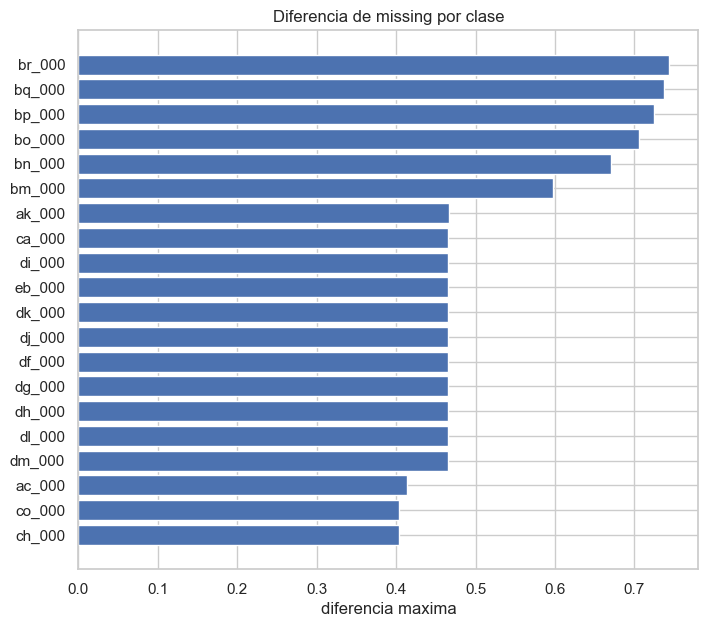

In [ ]:
plot_missing_class = missing_class_diff.head(20).sort_values("max_difference")

if len(class_cols) >= 2:
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(plot_missing_class["column"], plot_missing_class["max_difference"])
    ax.set_title("Diferencia de missing por clase")
    ax.set_xlabel("diferencia maxima")
    guardar_figura(fig, "artifacts/figures/missing_by_class_top20.png")
    plt.show()
else:
    print("No hay suficientes clases para comparar missing por clase")

La gráfica resume visualmente qué variables presentan las mayores diferencias de missing entre clases. Destacan **br_000**, **bq_000**, **bp_000**, **bo_000** y **bn_000**, con diferencias superiores al **0.65**.

Esta figura sirve para identificar rápidamente dónde está el contraste más fuerte.

## Resumen numérico

Esta sección calcula estadísticos de las variables numéricas. Se revisan medidas como media, dispersión y cuantiles para entender la escala de las variables.

Este análisis ayuda a decidir qué modelos necesitan escalado. Los modelos lineales y SVM son sensibles a la escala, mientras que los árboles suelen ser menos sensibles.

In [ ]:
numeric_cols = obtener_variables_numericas(train.drop(columns=[target]))

numeric_summary = train[numeric_cols].describe().T
numeric_summary["missing_rate"] = train[numeric_cols].isna().mean()
numeric_summary.to_csv("artifacts/tables/numeric_summary_train.csv")

numeric_summary.head(20)

,count,mean,std,min,25%,50%,75%,max,missing_rate
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06,0.000000
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02,0.772150
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09,0.055583
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09,0.247683
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04,0.041667
af_000,57500.0,1.100682e+01,2.097926e+02,0.0,0.0,0.0,0.0,2.007000e+04,0.041667
ag_000,59329.0,2.216364e+02,2.047846e+04,0.0,0.0,0.0,0.0,3.376892e+06,0.011183
ag_001,59329.0,9.757223e+02,3.420053e+04,0.0,0.0,0.0,0.0,4.109372e+06,0.011183
ag_002,59329.0,8.606015e+03,1.503220e+05,0.0,0.0,0.0,0.0,1.055286e+07,0.011183
ag_003,59329.0,8.859128e+04,7.617312e+05,0.0,0.0,0.0,0.0,6.340207e+07,0.011183


El resumen confirma que las variables tienen escalas muy diferentes. Algunas variables trabajan con valores pequeños, mientras que otras alcanzan máximos muy altos. También se observa que muchas columnas tienen mediana igual a **0**, pero máximos muy elevados. Esto indica distribuciones muy asimétricas y presencia de valores extremos.

Esta estructura es habitual en datos de sensores y contadores industriales. Muchas señales pueden estar a cero durante un funcionamiento normal y crecer mucho cuando aparece una condición concreta del sistema.

Estas diferencias afectan sobre todo a modelos lineales y a SVM, porque son sensibles a la escala de las variables. Por eso el escalado se aplicará dentro del pipeline cuando corresponda. Así, cada fold de validación cruzada aprende el escalado solo con su parte de entrenamiento y se evita fuga de información.

Los modelos basados en árboles suelen ser menos sensibles a la escala, pero siguen necesitando un tratamiento correcto de los valores faltantes. Por eso la imputación se mantiene como paso común del preprocesamiento.

## Outliers con IQR

Esta sección identifica valores extremos con la regla del rango intercuartílico. El objetivo no es eliminar observaciones, sino medir hasta qué punto las variables tienen distribuciones con muchos ceros, colas largas y valores alejados del rango central.

En este dataset, los outliers deben interpretarse con cuidado. Las variables proceden de sensores y agregados internos del camión, por lo que un valor extremo puede representar una situación real del sistema. En un problema de mantenimiento predictivo, esos valores pueden ser precisamente los que ayudan a detectar un fallo APS.

In [ ]:
outlier_rows = []

for col in numeric_cols:
    s = train[col].dropna()
    if s.empty:
        outlier_rows.append({
            "column": col,
            "outlier_count": 0,
            "outlier_rate": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "iqr": np.nan
        })
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier_count = int(((s < low) | (s > high)).sum())
    outlier_rate = outlier_count / len(s)

    outlier_rows.append({
        "column": col,
        "outlier_count": outlier_count,
        "outlier_rate": outlier_rate,
        "q1": q1,
        "q3": q3,
        "iqr": iqr
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_rate", ascending=False)
outlier_summary.to_csv("artifacts/metrics/outlier_summary_train.csv", index=False)
outlier_summary.head(20)

,column,outlier_count,outlier_rate,q1,q3,iqr
49,az_007,14235,0.239933,0.0,0.0,0.0
146,dr_000,13007,0.227101,0.0,0.0,0.0
145,dq_000,12870,0.224709,0.0,0.0,0.0
74,bn_000,3509,0.219436,171720.0,493100.0,321380.0
60,ba_008,12580,0.212099,0.0,1820.0,1820.0
95,cj_000,12540,0.210184,0.0,0.0,0.0
18,aj_000,12452,0.209732,0.0,0.0,0.0
9,ag_003,12435,0.209594,0.0,0.0,0.0
152,dy_000,11867,0.207190,0.0,36.0,36.0
151,dx_000,11572,0.202036,0.0,8764.0,8764.0


La tabla muestra que varias variables tienen una proporción alta de valores extremos. Algunas, como **az_007**, **dr_000**, **dq_000**, **cj_000** o **aj_000**, tienen un rango intercuartílico igual a **0**. Esto indica que la mayoría de sus valores están concentrados en **0**, pero existen casos con valores distintos y alejados del patrón habitual.

Este comportamiento es coherente con variables de sensores o contadores industriales. Muchas señales pueden permanecer inactivas durante el funcionamiento normal y activarse solo en condiciones concretas.

Por eso no se eliminan outliers de forma automática. Quitarlos podría borrar señales útiles para detectar fallos APS. La decisión más prudente es documentar su presencia, conservar las variables y usar modelos capaces de manejar distribuciones asimétricas, como árboles y métodos de boosting.

## Gráfica de outliers

Esta figura muestra boxplots de algunas variables con alta presencia de valores extremos. El objetivo es ver de forma visual cómo se distribuyen sus valores y comprobar si existen colas largas, concentraciones en valores bajos y observaciones muy alejadas del resto.

Esta revisión complementa la tabla anterior. La tabla resume cuántos outliers hay, pero la figura ayuda a entender mejor la forma de la distribución. Esto es importante porque en datos industriales los valores extremos no siempre son errores. En muchos casos pueden estar relacionados con comportamientos anómalos del sistema.

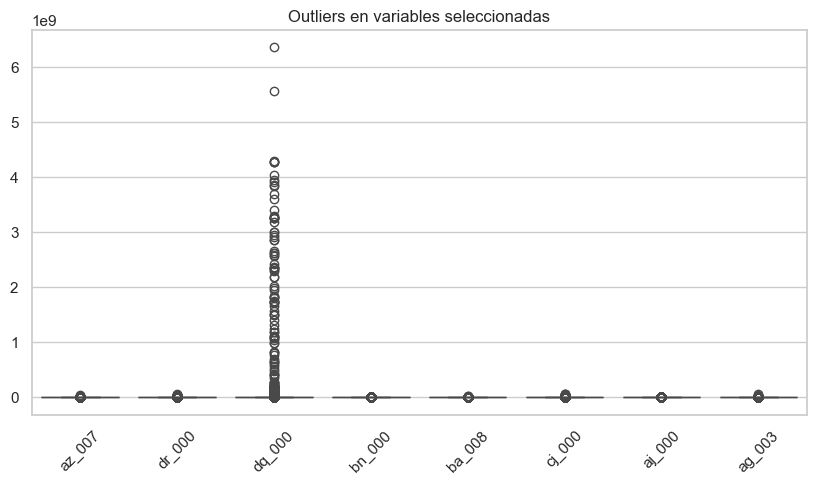

In [ ]:
selected_outlier_cols = outlier_summary.head(8)["column"].tolist()

if selected_outlier_cols:
    data_box = train[selected_outlier_cols].copy()
    data_box = data_box.replace([np.inf, -np.inf], np.nan)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=data_box, ax=ax)
    ax.set_title("Outliers en variables seleccionadas")
    ax.tick_params(axis="x", rotation=45)
    guardar_figura(fig, "artifacts/figures/boxplots_selected_variables.png")
    plt.show()
else:
    print("No hay variables numericas para graficar")

Los boxplots confirman que varias variables presentan distribuciones muy asimétricas. En la mayoría de los casos, gran parte de los valores se concentra cerca de la zona baja, mientras que aparece un conjunto reducido de observaciones muy altas.

La variable **dq_000** destaca de forma clara, con valores extremos mucho más alejados que el resto. En las demás variables también se observan outliers, aunque en una escala menor. Esto sugiere que el dataset contiene señales muy desiguales y con colas largas, algo bastante habitual en datos de sensores.

Este patrón es importante para el modelado. No parece razonable asumir distribuciones limpias o aproximadamente simétricas en todas las variables. Por eso tiene sentido comparar modelos más flexibles, especialmente métodos basados en árboles y boosting, que suelen adaptarse mejor a este tipo de datos.

En este notebook no se eliminan los valores extremos. Se conservan porque podrían contener información útil para detectar fallos APS.

## Correlaciones sencillas

Esta sección calcula una matriz de correlación sobre un subconjunto de variables. Se seleccionan columnas con suficiente información para que la matriz sea interpretable.

El objetivo es detectar relaciones generales entre sensores y posible redundancia. No se usa la matriz para seleccionar variables manualmente.

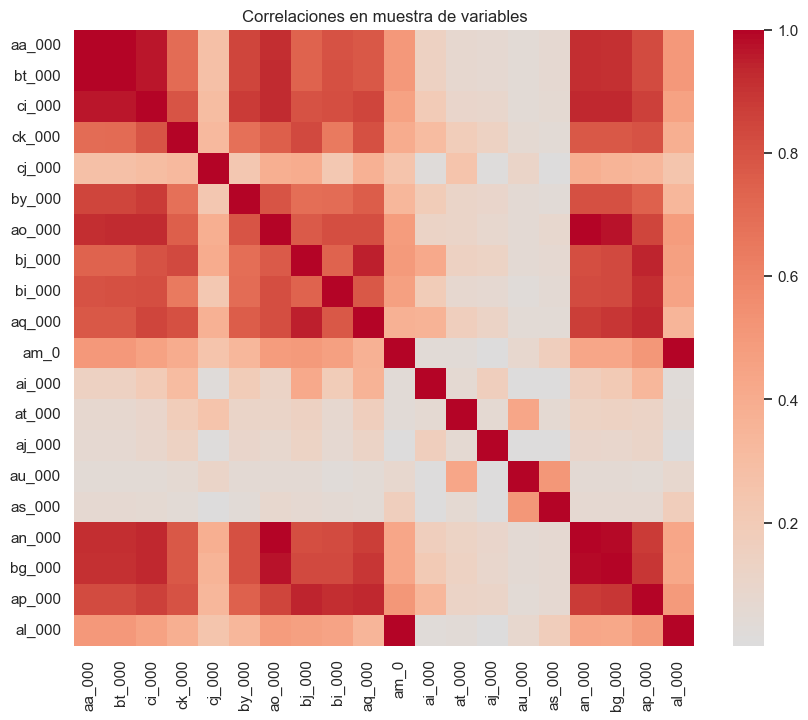

,aa_000,bt_000,ci_000,ck_000,cj_000,by_000,ao_000,bj_000,bi_000,aq_000,am_0,ai_000,at_000,aj_000,au_000,as_000,an_000,bg_000,ap_000,al_000
aa_000,1.000000,1.000000,0.965346,0.702700,0.273722,0.845767,0.920302,0.735951,0.804664,0.779180,0.503724,0.141642,0.070577,0.064064,0.043807,0.068093,0.915273,0.907884,0.822415,0.500743
bt_000,1.000000,1.000000,0.966736,0.705829,0.273812,0.848063,0.922398,0.736662,0.805575,0.780943,0.503735,0.141642,0.070567,0.064057,0.043802,0.068095,0.917501,0.910343,0.823350,0.500803
ci_000,0.965346,0.966736,1.000000,0.795762,0.299361,0.876255,0.922083,0.800728,0.812939,0.851588,0.459815,0.196346,0.098856,0.090552,0.044145,0.060545,0.932331,0.931069,0.864672,0.454417
ck_000,0.702700,0.705829,0.795762,1.000000,0.321182,0.680599,0.751841,0.834279,0.645277,0.809097,0.398669,0.305775,0.183825,0.133677,0.060359,0.045813,0.777570,0.779385,0.802977,0.386503
cj_000,0.273722,0.273812,0.299361,0.321182,1.000000,0.231155,0.386513,0.402999,0.220817,0.370107,0.254462,0.020860,0.257530,0.013737,0.109734,0.004057,0.383497,0.355326,0.341683,0.242851
by_000,0.845767,0.848063,0.876255,0.680599,0.231155,1.000000,0.793823,0.693424,0.695576,0.764967,0.343231,0.187828,0.115504,0.096401,0.050649,0.037378,0.810511,0.805024,0.743608,0.337346
ao_000,0.920302,0.922398,0.922083,0.751841,0.386513,0.793823,1.000000,0.770789,0.817152,0.818382,0.490278,0.117794,0.112910,0.079747,0.050743,0.079306,0.992997,0.974085,0.848709,0.490500
bj_000,0.735951,0.736662,0.800728,0.834279,0.402999,0.693424,0.770789,1.000000,0.735587,0.952327,0.494319,0.416835,0.146806,0.130660,0.052916,0.068731,0.813263,0.832733,0.945185,0.467383
bi_000,0.804664,0.805575,0.812939,0.645277,0.220817,0.695576,0.817152,0.735587,1.000000,0.773813,0.465843,0.195235,0.075793,0.068386,0.028718,0.054463,0.827631,0.830323,0.916789,0.452096
aq_000,0.779180,0.780943,0.851588,0.809097,0.370107,0.764967,0.818382,0.952327,0.773813,1.000000,0.370099,0.366472,0.167727,0.120589,0.045396,0.042857,0.871476,0.897438,0.935372,0.351059


In [ ]:
if numeric_cols:
    corr_candidates = numeric_summary.copy()
    corr_candidates["variance"] = train[numeric_cols].var(numeric_only=True)
    corr_candidates = corr_candidates.sort_values(["missing_rate", "variance"], ascending=[True, False])
    corr_cols = corr_candidates.head(20).index.tolist()
    corr_matrix = train[corr_cols].corr()
    corr_matrix.to_csv("artifacts/tables/correlation_sample_train.csv")

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Correlaciones en muestra de variables")
    guardar_figura(fig, "artifacts/figures/correlation_sample_train.png")
    plt.show()
else:
    corr_matrix = pd.DataFrame()
    print("No hay variables numericas para correlacion")

corr_matrix

La matriz muestra varias correlaciones altas entre variables. Por ejemplo, **aa_000** y **bt_000** tienen una correlación prácticamente perfecta, y también aparecen relaciones muy fuertes entre **ao_000**, **an_000** y **bg_000**. Esto sugiere que algunas columnas contienen información parecida o proceden de señales relacionadas del sistema.

Esta redundancia no es necesariamente un problema. En datos de sensores es habitual que varias medidas describan partes cercanas del mismo proceso. Para modelos lineales puede ser útil aplicar regularización, mientras que los modelos basados en árboles y boosting suelen manejar mejor este tipo de relaciones.

La matriz se usa solo como análisis exploratorio. No se eliminan variables de forma manual a partir de estas correlaciones. La comparación de modelos se hará con las mismas variables procesadas de forma consistente y sin utilizar test para tomar decisiones.

## Accuracy engañosa

Esta celda calcula la accuracy que se obtendría prediciendo siempre la clase mayoritaria. El objetivo es mostrar por qué una métrica global puede ser engañosa en un dataset tan desbalanceado.

En train, la clase positiva representa solo el **1.67%** de los casos. Por eso, un modelo que predijera siempre la clase negativa alcanzaría una accuracy muy alta, aunque no detectaría ningún fallo APS.

In [ ]:
majority_class = train[target].mode().iloc[0]
majority_accuracy = float((train[target] == majority_class).mean())
positive_rate_observed = float((train[target] == positive_label).mean()) if positive_label in set(train[target].unique()) else np.nan

accuracy_warning = pd.DataFrame({
    "metric": ["majority_class", "accuracy_predicting_majority", "positive_rate"],
    "value": [majority_class, majority_accuracy, positive_rate_observed]
})

accuracy_warning.to_csv("artifacts/metrics/accuracy_warning_train.csv", index=False)
accuracy_warning

,metric,value
0,majority_class,0.000000
1,accuracy_predicting_majority,0.983333
2,positive_rate,0.016667


Predecir siempre la clase negativa daría una accuracy de **98.33%** en train. Este resultado parece excelente si se mira solo el porcentaje total de aciertos, pero sería inútil para el objetivo real del proyecto porque dejaría sin detectar todos los fallos APS.

Esta observación justifica el uso de un baseline en el modelado supervisado. También explica por qué las métricas principales deben centrarse en la clase positiva. En este proyecto son más informativas métricas como **recall positivo**, **F1**, **PR-AUC** y **coste asimétrico**.

La accuracy se mantiene como métrica complementaria, pero no debe ser el criterio principal para valorar el sistema.

## Métricas del proyecto

Esta sección guarda una guía de métricas para el resto del proyecto. Recall positivo mide la proporción de fallos APS detectados. F1 resume el equilibrio entre precision y recall. PR-AUC evalúa la calidad del ranking cuando la clase positiva es minoritaria.

Balanced accuracy corrige el dominio de la clase negativa. El coste asimétrico traduce los errores a una lectura más cercana al mantenimiento real.

In [ ]:
metric_guidance = pd.DataFrame({
    "metric": ["accuracy", "recall_pos", "f1_pos", "pr_auc", "coste"],
    "use": [
        "referencia general",
        "detectar fallos APS",
        "equilibrar precision y recall",
        "evaluar clase positiva minoritaria",
        "reflejar errores con impacto distinto"
    ],
    "main_reason": [
        "puede enganar con desbalanceo",
        "reduce falsos negativos",
        "resume rendimiento en la clase positiva",
        "es mas informativa con positivos escasos",
        "un falso negativo puede ser mucho mas caro"
    ]
})

metric_guidance.to_csv("artifacts/tables/metric_guidance.csv", index=False)
metric_guidance

,metric,use,main_reason
0,accuracy,referencia general,puede enganar con desbalanceo
1,recall_pos,detectar fallos APS,reduce falsos negativos
2,f1_pos,equilibrar precision y recall,resume rendimiento en la clase positiva
3,pr_auc,evaluar clase positiva minoritaria,es mas informativa con positivos escasos
4,coste,reflejar errores con impacto distinto,un falso negativo puede ser mucho mas caro


Las métricas elegidas encajan con el problema real. El objetivo no es solo acertar muchas filas, sino detectar fallos APS sin disparar revisiones innecesarias.

Por eso el proyecto combinará métricas estadísticas y coste operativo. Esta combinación permite defender mejor las decisiones que una única métrica aislada.

## Conclusiones del EDA

El EDA muestra un dataset tabular grande, desbalanceado, con valores faltantes y valores extremos. Los datos de sensores no están limpios ni equilibrados.

Las conclusiones del análisis afectan directamente al modelado. El desbalanceo justifica el uso de **PR-AUC**, **recall**, **F1** y **coste asimétrico**. Los valores faltantes justifican la imputación dentro del **Pipeline**. Las escalas diferentes justifican el escalado en modelos lineales y SVM. La presencia de valores extremos y relaciones no lineales justifica comparar también modelos de árboles y boosting.

Todas estas decisiones se toman usando solo **train**. Test no se carga ni se analiza en este notebook. Esto permite entender el dataset y preparar el experimento sin comprometer la evaluación final.